# STAT 248 Final Project: Volatility Clustering in S&P 500 Returns

**Sumeng Xu — Spring 2026**

## Question
Do daily S&P 500 returns exhibit volatility clustering, and does a model with time-varying volatility (GARCH) describe market risk better than a constant-volatility benchmark? In addition, does the strength of clustering and the implied risk dynamics differ between the pre-2020 and post-2020 sub-periods?

## Data
Daily S&P 500 closing prices from FRED (Federal Reserve Bank of St. Louis), April 18, 2016 – April 15, 2026. Raw file: `SP500.csv`. After log-differencing and dropping NAs we obtain a return series of 2,512 daily observations, saved to `SP500_clean.csv`.

## Roadmap
0. Setup and data preparation (load and clean raw data)
1. Exploratory data analysis
2. Detecting volatility clustering (ACF, Ljung-Box)
3. Constant-volatility baseline and its diagnostic failures
4. GARCH(1,1) fit and residual diagnostics
5. Pre-2020 vs post-2020 sub-sample comparison
6. Risk-management implication: 1-day Value-at-Risk and Kupiec backtests
7. Conclusion



## Section 0 — Setup and Data Preparation

Below we first import packages, then load the raw FRED file `SP500.csv`, then rename columns, parse dates, sort, drop missing values, and lastly compute daily log returns

$$ r_t = \log P_t - \log P_{t-1} $$

before saving the cleaned series to `SP500_clean.csv`. Log returns are used because they are approximately additive over time and are the standard input for volatility modeling.


In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# read local csv file
sp500 = pd.read_csv("SP500.csv")

# look at the data
print(sp500.head())
print(sp500.columns)
print(sp500.shape)

  observation_date    SP500
0       2016-04-18  2094.34
1       2016-04-19  2100.80
2       2016-04-20  2102.40
3       2016-04-21  2091.48
4       2016-04-22  2091.58
Index(['observation_date', 'SP500'], dtype='str')
(2608, 2)


In [67]:
# rename columns
sp500 = sp500.rename(columns={"observation_date": "Date", "SP500": "Close"})

# convert Date to datetime
sp500["Date"] = pd.to_datetime(sp500["Date"])

# sort by date
sp500 = sp500.sort_values("Date")

# drop missing values
sp500 = sp500.dropna()

# compute log returns
sp500["log_return"] = np.log(sp500["Close"]).diff()

# drop first NA created by differencing
sp500 = sp500.dropna()

# check result
print(sp500.head())
print(sp500.shape)

        Date    Close  log_return
1 2016-04-19  2100.80    0.003080
2 2016-04-20  2102.40    0.000761
3 2016-04-21  2091.48   -0.005208
4 2016-04-22  2091.58    0.000048
5 2016-04-25  2087.79   -0.001814
(2512, 3)


In [68]:
# save the cleaned data to a new csv file
sp500.to_csv("SP500_clean.csv", index=False)

## Section 1 — Exploratory Data Analysis

We reload the cleaned series, summarize it, and look at three plots on a common time axis: the price level, log returns, and squared returns. Squared returns are a noisy proxy for instantaneous variance. Clusters of large squared returns are the visual signature of volatility clustering.

We also run an ADF test to confirm that returns are stationary (a prerequisite for the models that follow), while the price level itself is non-stationary.

In [ ]:
# reload the cleaned returns so this section runs independently of Section 0
sp500   = pd.read_csv("SP500_clean.csv", parse_dates=["Date"]).set_index("Date").sort_index()
returns = sp500["log_return"]

from scipy import stats as sps
summary = pd.Series({
    "n_obs": len(returns),
    "mean": returns.mean(),
    "std": returns.std(),
    "min": returns.min(),
    "max": returns.max(),
    "skew": returns.skew(),
    "excess_kurtosis": returns.kurtosis(),  # 0 for a Normal
})
print(summary.to_string(float_format=lambda x: f"{x:.6f}"))


n_obs             2512.000000
mean                 0.000482
std                  0.011408
min                 -0.127652
max                  0.090895
skew                -0.685510
excess_kurtosis     16.860876


Mean daily log return is +0.048%, modestly positive (≈ 12% / year compounded). Daily SD is 1.14%. The return distribution is **left-skewed** (skew = −0.69) and has **massive excess kurtosis (16.9 vs 0 for a Normal)**, meaning extreme moves, especially large drops, are far more frequent than a Normal model would predict. The two extremes (−12.8% and +9.1% on a single day) are consistent with the COVID crash and rebound in March 2020.

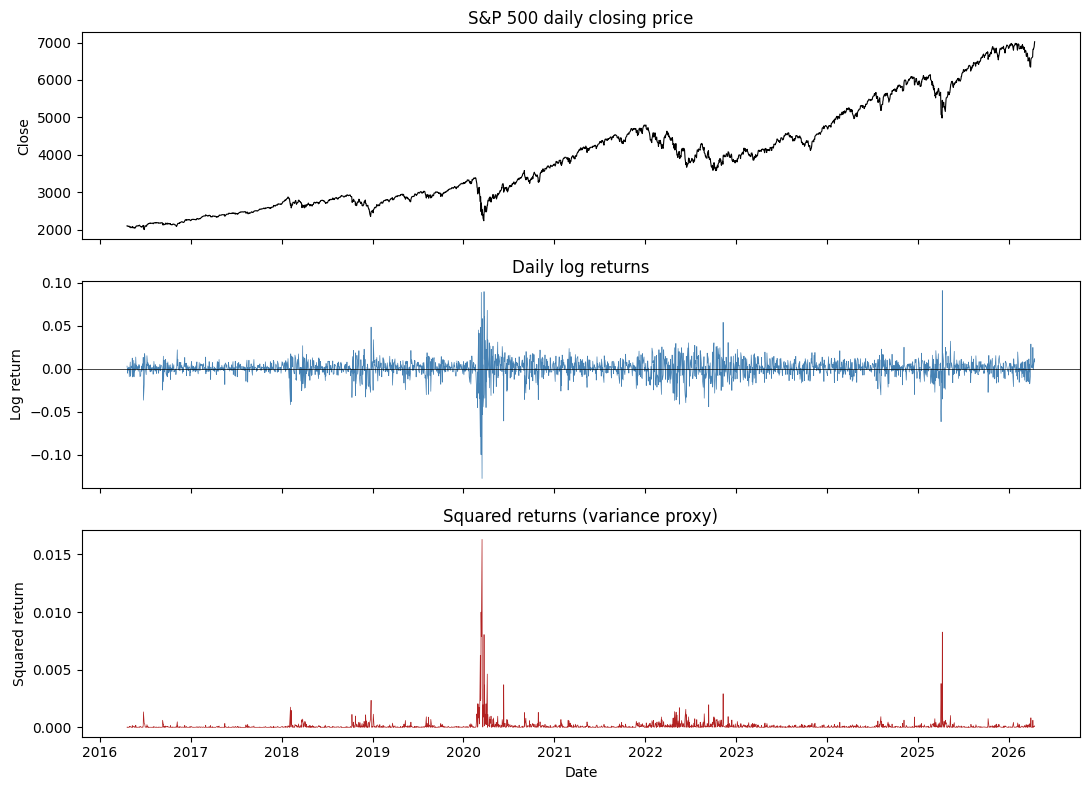

In [70]:
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)

axes[0].plot(sp500["Close"], color="black", lw=0.8)
axes[0].set_ylabel("Close")
axes[0].set_title("S&P 500 daily closing price")

axes[1].plot(returns, color="steelblue", lw=0.5)
axes[1].axhline(0, color="black", lw=0.5)
axes[1].set_ylabel("Log return")
axes[1].set_title("Daily log returns")

axes[2].plot(returns**2, color="firebrick", lw=0.5)
axes[2].set_ylabel("Squared return")
axes[2].set_xlabel("Date")
axes[2].set_title("Squared returns (variance proxy)")

plt.tight_layout()
plt.show()


The above three figures:

- *Top - price.* The S&P 500 trends upward over the decade with three obvious drawdowns (early 2020, 2022, and a mid-2025 dip), separated by extended bull-market stretches.
- *Middle - log returns.* Returns oscillate around zero, but the **amplitude is visibly non-uniform**: 2017–2019 looks calm, March 2020 explodes, and post-2020 sustains a higher baseline of jitter. Non-constant amplitude is volatility clustering.
- *Bottom - squared returns.* Clusters of large $r_t^2$ are unmistakable around March 2020, mid-2022, and again in 2025. Long calm stretches sit in between. This is the visual case for modeling time-varying variance.

In [ ]:
from statsmodels.tsa.stattools import adfuller

def adf_report(series, name):
    stat, pval, *_ = adfuller(series.dropna(), autolag="AIC")
    print(f"ADF on {name:12s}  stat={stat: .4f}  p-value={pval:.4f}")

adf_report(np.log(sp500["Close"]), "log price")
adf_report(returns, "log return")


ADF on log price     stat=-0.5479  p-value=0.8823
ADF on log return    stat=-15.8634  p-value=0.0000


**ADF results:** The log price series cannot reject a unit root (stat = −0.55, p = 0.88).It is non-stationary, as expected for an index. The log-return series strongly rejects (stat = −15.86, p < $10^{-5}$), returns are stationary. This follows the standard pattern for financial prices and confirms that working with log returns is the right level of differencing for the volatility models that follow.

## Section 2 — Detecting Volatility Clustering

Volatility clustering means that the magnitude of returns is autocorrelated: large moves tend to be followed by large moves. We diagnose it with two complementary tools:

- ACF / PACF of raw returns - should be about 0 at all lags if the market is approximately efficient.
- ACF of squared returns - strong, slowly decaying autocorrelations are the hallmark of volatility clustering.

We back this up with the Ljung-Box portmanteau test on returns and on squared returns. A non-rejection on returns plus a strong rejection on squared returns is the canonical signature.


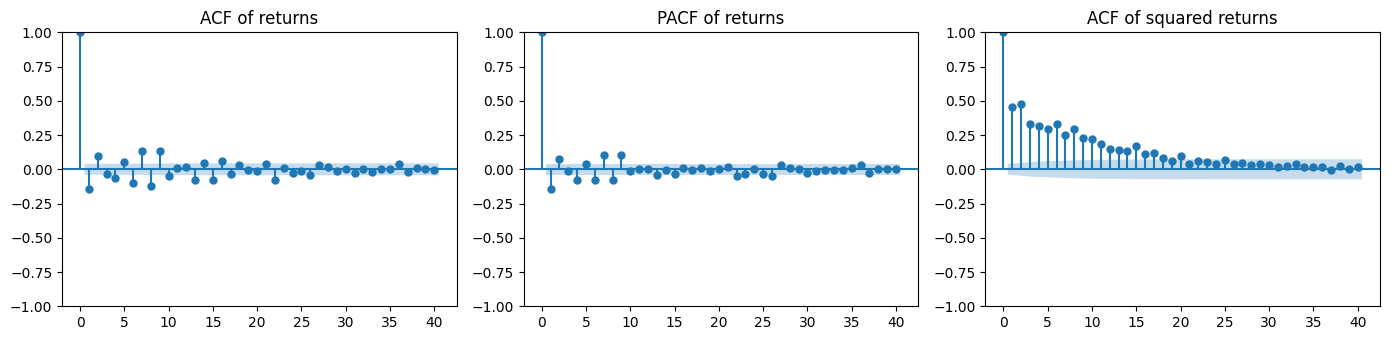

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
plot_acf (returns, lags=40, ax=axes[0]); axes[0].set_title("ACF of returns")
plot_pacf(returns, lags=40, ax=axes[1], method="ywm"); axes[1].set_title("PACF of returns")
plot_acf (returns**2, lags=40, ax=axes[2]); axes[2].set_title("ACF of squared returns")
plt.tight_layout()
plt.show()


**ACF / PACF.** Returns themselves show only a few small spikes barely outside the band, which are economically tiny. The ACF of squared returns, in contrast, is strongly significant well past lag 40 and decays slowly. Returns are nearly serially uncorrelated, but the magnitude of returns is highly serially dependent. That is the classic fingerprint of conditional heteroskedasticity.

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lags = [5, 10, 20]
lb_r  = acorr_ljungbox(returns, lags=lags, return_df=True)
lb_r2 = acorr_ljungbox(returns**2, lags=lags, return_df=True)

print("Ljung-Box on returns (H0: no autocorrelation)")
print(lb_r .to_string(float_format=lambda x: f"{x:.4g}"))
print("\nLjung-Box on squared returns (H0: no autocorrelation)")
print(lb_r2.to_string(float_format=lambda x: f"{x:.4g}"))


Ljung-Box on returns (H0: no autocorrelation)
    lb_stat  lb_pvalue
5     94.29  8.409e-19
10    252.2  1.891e-48
20    304.9  8.044e-53

Ljung-Box on squared returns (H0: no autocorrelation)
    lb_stat  lb_pvalue
5      1825          0
10     2731          0
20     3161          0


**Ljung-Box.** Both tests reject $H_0$, but on very different scales. On raw returns the LB statistic at lag 20 is ≈ 305 : significant, but moderate. On squared returns it is ≈ 3,161, more than 10× larger, with p-values numerically zero. The dependence structure in the data sits overwhelmingly in the *variance*, not in the conditional mean. So an ARMA model on the mean wouldn't help much, the structure I want to capture is in the variance.

## Section 3 — Constant-Volatility Baseline

The simplest possible model treats every day as i.i.d. with constant variance:

$$ r_t = \mu + \sigma\,\varepsilon_t, \qquad \varepsilon_t \stackrel{\text{iid}}{\sim} \mathcal{N}(0,1) $$

We estimate $\hat\mu = \bar r$ and $\hat\sigma = s_r$, build standardized residuals $z_t = (r_t - \hat\mu)/\hat\sigma$, and ask whether the $z_t$ behave like i.i.d. Normals.

The crucial check is Ljung-Box on $z_t^2$. If squared standardized residuals are still autocorrelated, the constant-volatility model has failed to capture the clustering structure, and we need a model that lets variance evolve. We also look at a Normal QQ plot and the Jarque-Bera test for tail behavior.


mu_hat    = 0.000482
sigma_hat = 0.011408

Ljung-Box on z   (residuals):
    lb_stat  lb_pvalue
10    252.2  1.891e-48
20    304.9  8.044e-53

Ljung-Box on z^2 (squared residuals -- clustering check):
    lb_stat  lb_pvalue
10     2730          0
20     3159          0

Jarque-Bera on z:  stat=29825.42  p-value=0


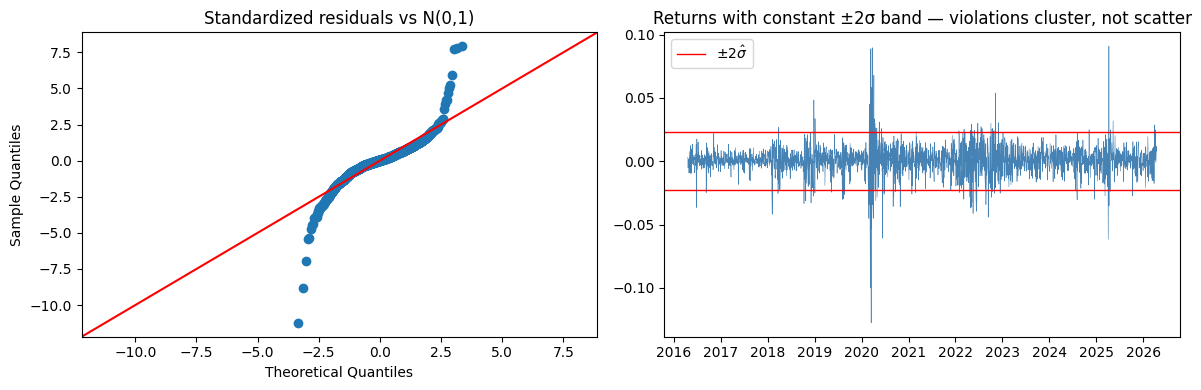

In [ ]:
import statsmodels.api as sm

mu_hat    = returns.mean()
sigma_hat = returns.std()
print(f"mu_hat = {mu_hat:.6f}")
print(f"sigma_hat = {sigma_hat:.6f}")

z = (returns - mu_hat) / sigma_hat   # standardized residuals

# Ljung-Box on z and z^2 : the key clustering check
lb_z  = acorr_ljungbox(z,lags=[10, 20], return_df=True)
lb_z2 = acorr_ljungbox(z**2,lags=[10, 20], return_df=True)

print("\nLjung-Box on z   (residuals):")
print(lb_z .to_string(float_format=lambda x: f"{x:.4g}"))
print("\nLjung-Box on z^2 (squared residuals -- clustering check):")
print(lb_z2.to_string(float_format=lambda x: f"{x:.4g}"))

# normality
jb_stat, jb_p = sps.jarque_bera(z)
print(f"\nJarque-Bera on z:  stat={jb_stat:.2f}  p-value={jb_p:.4g}")

# QQ plot + constant +/- 2 sigma band on the return series
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sm.qqplot(z, line="45", ax=axes[0])
axes[0].set_title("Standardized residuals vs N(0,1)")

axes[1].plot(returns, color="steelblue", lw=0.4)
axes[1].axhline( 2*sigma_hat, color="red", lw=1, label=r"$\pm 2\hat\sigma$")
axes[1].axhline(-2*sigma_hat, color="red", lw=1)
axes[1].set_title("Returns with constant ±2σ band — violations cluster, not scatter")
axes[1].legend()
plt.tight_layout()
plt.show()

**Baseline diagnostics:** With $\hat\mu = 4.8\times 10^{-4}$ and $\hat\sigma = 1.14\times 10^{-2}$, the standardized residuals $z_t$ inherit the dependence structure of $r_t^2$: Ljung-Box on $z_t^2$ produces enormous test statistics with p-values of zero. Jarque–Bera rejects normality decisively, and the QQ plot shows heavy departures from the 45° line in both tails - consistent with the excess kurtosis of 16.9. Visually, the **±2σ band is breached in clusters** (especially in 2020 and 2022) rather than scattered uniformly. Constant volatility fails exactly the diagnostic it should: it ignores clustering, and the residuals tell us so.

## Section 4 — GARCH(1,1)

A GARCH(1,1) model lets the conditional variance respond to recent shocks and to its own past:

$$ r_t = \mu + \sigma_t\,\varepsilon_t, \qquad \sigma_t^2 = \omega + \alpha\,(r_{t-1}-\mu)^2 + \beta\,\sigma_{t-1}^2 $$

The coefficient $\alpha$ measures how strongly today's variance reacts to yesterday's shock; $\beta$ is the persistence of past variance. $\alpha+\beta$ summarizes how slowly volatility decays back to its long-run level (close to 1 = very persistent).

We fit GARCH(1,1) with Normal innovations using the `arch` package, run the same diagnostic suite on its standardized residuals, and then refit with Student-$t$ innovations as a robustness check, motivated by the fat tails seen in Section 3.


In [ ]:
from arch import arch_model

# arch_model expects returns in percent for numerical stability
returns_pct = returns * 100

garch_n = arch_model(returns_pct, mean="constant", vol="GARCH", p=1, q=1, dist="normal")
res_n = garch_n.fit(disp="off")
print(res_n.summary())

alpha = res_n.params["alpha[1]"]
beta = res_n.params["beta[1]"]
print(f"\npersistence alpha + beta = {alpha + beta:.4f}")


                     Constant Mean - GARCH Model Results                      
Dep. Variable:             log_return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3231.23
Distribution:                  Normal   AIC:                           6470.47
Method:            Maximum Likelihood   BIC:                           6493.78
                                        No. Observations:                 2512
Date:                Wed, May 06 2026   Df Residuals:                     2511
Time:                        22:56:58   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0796  1.494e-02      5.327  9.963e-08 [5.032e-0

**GARCH(1,1)-Normal estimates.** $\hat\alpha = 0.172$, $\hat\beta = 0.798$, persistence $\hat\alpha + \hat\beta = 0.97$. Roughly 17% of yesterday's squared shock and 80% of yesterday's variance carry over into today. Persistence near one means volatility shocks **decay slowly**. A high-vol regime, once entered, takes a long time to fade. All three coefficients are highly significant.

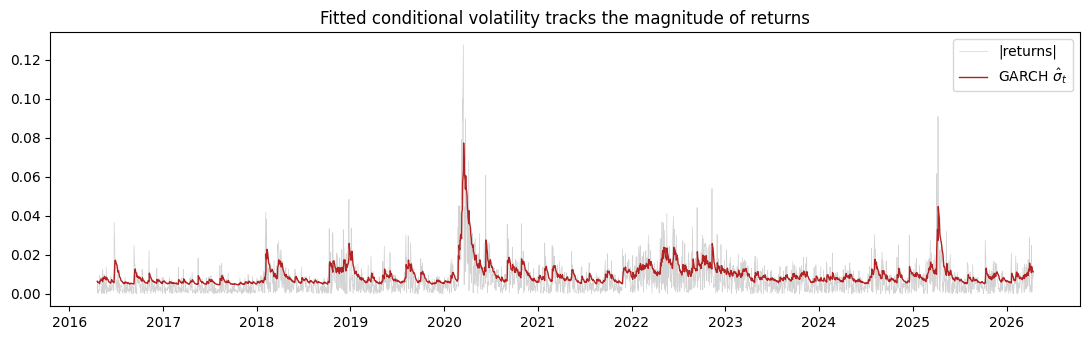

Ljung-Box on GARCH std. residuals:
    lb_stat  lb_pvalue
10    6.771     0.7469
20    17.77     0.6025

Ljung-Box on squared GARCH std. residuals:
    lb_stat  lb_pvalue
10    10.89     0.3665
20    13.16     0.8704


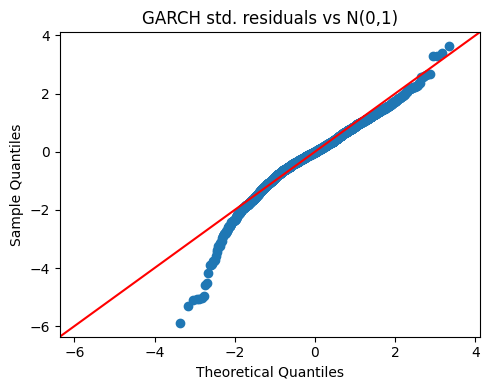

In [ ]:
# conditional volatility back on the raw return scale
cond_vol = res_n.conditional_volatility / 100

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(returns.abs(), color="lightgray", lw=0.5, label="|returns|")
ax.plot(cond_vol, color="firebrick", lw=1, label=r"GARCH $\hat\sigma_t$")
ax.set_title("Fitted conditional volatility tracks the magnitude of returns")
ax.legend()
plt.tight_layout()
plt.show()

# standardized residuals
z_g = res_n.resid / res_n.conditional_volatility

lb_zg = acorr_ljungbox(z_g, lags=[10, 20], return_df=True)
lb_zg2 = acorr_ljungbox(z_g**2, lags=[10, 20], return_df=True)
print("Ljung-Box on GARCH std. residuals:")
print(lb_zg.to_string(float_format=lambda x: f"{x:.4g}"))
print("\nLjung-Box on squared GARCH std. residuals:")
print(lb_zg2.to_string(float_format=lambda x: f"{x:.4g}"))

fig, ax = plt.subplots(figsize=(5, 4))
sm.qqplot(z_g.dropna(), line="45", ax=ax)
ax.set_title("GARCH std. residuals vs N(0,1)")
plt.tight_layout()
plt.show()


**GARCH-Normal diagnostics.** The fitted $\hat\sigma_t$ tracks the magnitude of returns very closely: flat in calm periods, expanding sharply in March 2020 and during 2022. On the standardized residuals the Ljung-Box statistics on $z_t^2$ drop sharply versus the constant-vol baseline, indicating that GARCH has absorbed almost all of the clustering. However, the QQ plot still shows tail departures: GARCH explains the variance dynamics, but Normal innovations cannot match the fatness of the empirical tails. This motivates the Student t check next.

In [ ]:
garch_t = arch_model(returns_pct, mean="constant", vol="GARCH", p=1, q=1, dist="t")
res_t = garch_t.fit(disp="off")
print(res_t.summary())

# information-criterion comparison - fit constant-vol on returns_pct so scales match
mu_pct, sd_pct = returns_pct.mean(), returns_pct.std()
const_loglik = sps.norm.logpdf(returns_pct, loc=mu_pct, scale=sd_pct).sum()
n = len(returns_pct)
const_k = 2  # mu, sigma
const_aic = 2*const_k - 2*const_loglik
const_bic = const_k*np.log(n) - 2*const_loglik

ic_table = pd.DataFrame({
    "logL":[const_loglik, res_n.loglikelihood, res_t.loglikelihood],
    "AIC":[const_aic, res_n.aic, res_t.aic],
    "BIC":[const_bic, res_n.bic, res_t.bic],
}, index=["Constant-Normal", "GARCH(1,1)-Normal", "GARCH(1,1)-t"])
print("\nInformation criteria (lower is better):")
print(ic_table.round(2))


                        Constant Mean - GARCH Model Results                         
Dep. Variable:                   log_return   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -3124.54
Distribution:      Standardized Student's t   AIC:                           6259.08
Method:                  Maximum Likelihood   BIC:                           6288.23
                                              No. Observations:                 2512
Date:                      Wed, May 06 2026   Df Residuals:                     2511
Time:                              22:57:04   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu        

**GARCH-$t$ and information criteria.** The Student t fit estimates degrees of freedom $\hat\nu \approx 5.03$: strongly fat-tailed (a Normal corresponds to $\nu = \infty$, and the variance only exists for $\nu > 2$). Persistence ticks up to $0.17 + 0.83 \approx 1.00$, meaning the model is essentially **integrated**: variance shocks are nearly permanent within this sample. AIC and BIC drop by ≈ 1300 from the constant baseline to GARCH-Normal and by another ≈ 210 from GARCH-Normal to GARCH-$t$. Even after letting variance vary over time, the tails still need a fatter distribution.

## Section 5 — Pre-2020 vs Post-2020

Another interesting point to see is whether model behavior differs across sub-periods, with 2020 as a natural break point (COVID crash, large-scale fiscal/monetary response, then a markedly different macro regime, including the 2022 inflation/rate cycle, 2023 banking stress, and 2025 trade-policy shocks). We split the sample at **January 1, 2020** and refit the same models on each half.

For each sub-period we get:

- Sample standard deviation and excess kurtosis (fat-tail intensity)
- Ljung-Box on squared returns at lag 20 (clustering strength)
- GARCH(1,1)-$t$ parameters and persistence $\alpha+\beta$

We also plot a rolling 30-day annualized standard deviation across the full sample with the split date marked.

In [ ]:
split_date = "2020-01-01"
pre  = returns[returns.index <  split_date]
post = returns[returns.index >= split_date]

def period_summary(r, name):
    lb20 = acorr_ljungbox(r**2, lags=[20], return_df=True).iloc[0]
    return pd.Series({
        "n": len(r),
        "std": r.std(),
        "excess_kurtosis": r.kurtosis(),
        "LB(r^2,20) stat": lb20["lb_stat"],
        "LB(r^2,20) p": lb20["lb_pvalue"],
    }, name=name)

period_table = pd.concat([period_summary(pre,  "pre-2020"),
                          period_summary(post, "post-2020")], axis=1)
print(period_table.round(4))


                 pre-2020  post-2020
n                933.0000  1579.0000
std                0.0079     0.0131
excess_kurtosis    5.5800    14.7409
LB(r^2,20) stat  310.8630  1968.1074
LB(r^2,20) p       0.0000     0.0000


**Pre-2020 vs post-2020:** The post-2020 sample has a daily SD that is **66% higher** than pre-2020 (0.0131 vs 0.0079) and excess kurtosis that is **roughly 2.6× larger** (14.7 vs 5.6). The Ljung-Box statistic on squared returns at lag 20 jumps from 311 pre-2020 to 1968 post-2020, a 6× increase in the strength of the clustering signal. Even before fitting any model, the post-2020 sample is **more volatile, more fat-tailed, and more clustered**.

In [ ]:
def fit_garch_t(r):
    m = arch_model(r * 100, mean="constant", vol="GARCH", p=1, q=1, dist="t")
    return m.fit(disp="off")

res_pre  = fit_garch_t(pre)
res_post = fit_garch_t(post)

def garch_row(res, name):
    a = res.params["alpha[1]"]; b = res.params["beta[1]"]
    return pd.Series({
        "omega": res.params["omega"],
        "alpha": a,
        "beta": b,
        "persistence": a + b,
        "logL": res.loglikelihood,
        "AIC": res.aic,
    }, name=name)

garch_table = pd.concat([garch_row(res_pre,  "pre-2020"),
                         garch_row(res_post, "post-2020")], axis=1)
print(garch_table.round(4))


              pre-2020  post-2020
omega           0.0270     0.0390
alpha           0.2020     0.1535
beta            0.7780     0.8269
persistence     0.9799     0.9804
logL         -886.0260 -2227.6788
AIC          1782.0520  4465.3577


**Pre-2020 vs post-2020 GARCH dynamics.** Total persistence $\alpha+\beta$ is essentially identical across the two regimes (0.980 vs 0.980), but the **decomposition shifts**:

- Pre-2020 has **higher reactivity** ($\alpha = 0.20$) paired with a lower $\beta = 0.78$, so shocks hit the variance hard but die out comparatively quickly.
- Post-2020 has **lower reactivity** ($\alpha = 0.15$) but a **higher persistence** ($\beta = 0.83$), meaning individual shocks register with less amplitude in $\sigma_t^2$, but they get carried forward in memory more strongly.
- The intercept $\omega$ is also larger post-2020, lifting the long-run baseline variance.

post-2020 the market sits at a higher baseline tension, and once shocks hit they leak out more slowly even though the single-day reaction is muted.

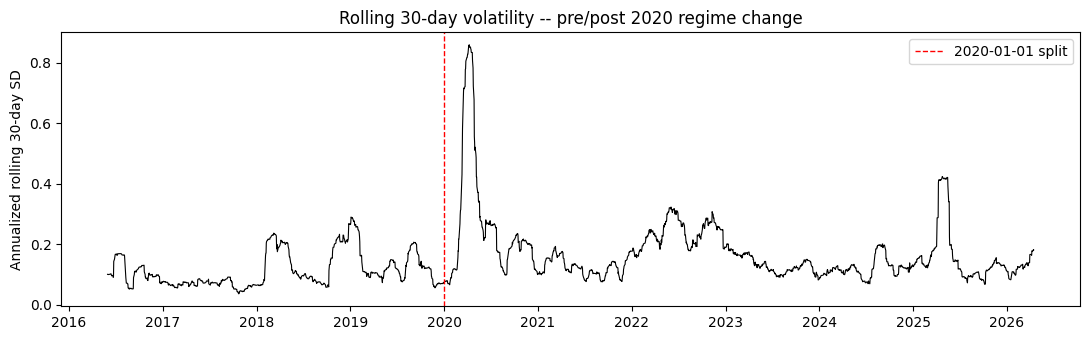

In [80]:
roll_std = returns.rolling(window=30).std() * np.sqrt(252)  # annualized

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(roll_std, color="black", lw=0.8)
ax.axvline(pd.Timestamp(split_date), color="red", ls="--", lw=1, label="2020-01-01 split")
ax.set_ylabel("Annualized rolling 30-day SD")
ax.set_title("Rolling 30-day volatility -- pre/post 2020 regime change")
ax.legend()
plt.tight_layout()
plt.show()


**Rolling volatility.** The 30-day rolling annualized SD makes the regime change visually obvious: pre-2020 sits mostly in the 5–15% band with one notable spike in early 2018; post-2020 spends most of its time at or above that pre-2020 ceiling, with the COVID episode reaching ≈ 75–90% annualized and a second sustained surge in 2022 (≈ 30%). The dashed red line marks the split date.

## Section 6 — Value-at-Risk

We want to see whether the model gives risk numbers that hold up. The 1-day 95% Value-at-Risk (VaR) is the loss level such that, on a typical day, the probability of a worse loss is 5%. Under each model:

- **Constant-volatility:**  $\mathrm{VaR}_t^{0.95} = -(\hat\mu + \hat\sigma\,q_{0.05})$, flat across time
- **GARCH(1,1)-$t$:**  $\mathrm{VaR}_t^{0.95} = -(\hat\mu + \hat\sigma_t\,q_{0.05,\nu})$, moving with the conditional variance

Here $q_{0.05}$ is the 5th-percentile quantile of the assumed innovation distribution. We back-test by counting the **violation rate** (fraction of days where the actual loss exceeds the VaR) and applying the **Kupiec unconditional coverage test**. A well-calibrated 95% VaR violates 5% of the time. We run the test on the full sample, pre-2020, and post-2020.

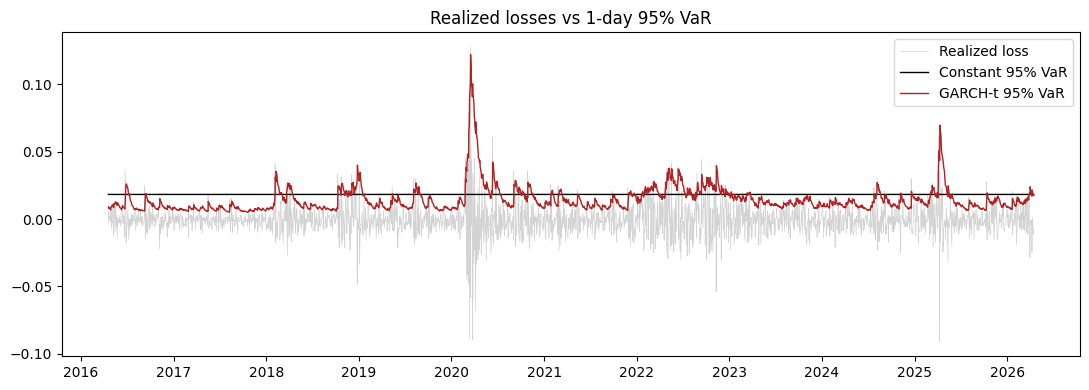

In [ ]:
alpha_var = 0.05

# constant-vol VaR 
z_q_n = sps.norm.ppf(alpha_var)    # ~ -1.645
const_var = -(mu_hat + sigma_hat * z_q_n) * np.ones(len(returns))

# GARCH-t VaR using the full-sample t-fit from Section 4
nu_t = res_t.params["nu"]
# arch's standardized-t innovation has unit variance, so rescale the quantile
z_q_t = sps.t.ppf(alpha_var, df=nu_t) * np.sqrt((nu_t - 2) / nu_t)
garch_mu = res_t.params["mu"] / 100
garch_sig = res_t.conditional_volatility / 100
garch_var = -(garch_mu + garch_sig * z_q_t)

var_df = pd.DataFrame({
    "loss": -returns,
    "VaR_const": const_var,
    "VaR_garch": garch_var.values,
}, index=returns.index)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(var_df.index, var_df["loss"],      color="lightgray", lw=0.5, label="Realized loss")
ax.plot(var_df.index, var_df["VaR_const"], color="black",     lw=1,   label="Constant 95% VaR")
ax.plot(var_df.index, var_df["VaR_garch"], color="firebrick", lw=1,   label="GARCH-t 95% VaR")
ax.set_title("Realized losses vs 1-day 95% VaR")
ax.legend()
plt.tight_layout()
plt.show()


**VaR plot.** The black line is the constant-vol VaR, flat at ≈ 1.83% loss per day. The red line is the GARCH-t VaR, which expands aggressively in 2020 and 2022 (well above 5% per day at the COVID peak) and contracts to under 1% in calm 2017–2019 stretches. The realized losses (gray) cross the black line in tight clusters, which is exactly the pattern a constant model cannot accommodate. The GARCH-t line tracks the size of the losses much more closely.

In [ ]:
def kupiec_pof(loss, var, alpha=0.05):
    # Proportion-of-failures (Kupiec) unconditional coverage LR test
    x = (loss > var).astype(int)
    n = len(x); k = int(x.sum())
    pi_hat = k / n
    if k == 0 or k == n:
        return n, k, pi_hat, np.nan, np.nan
    LR = -2 * (k*np.log(alpha) + (n-k)*np.log(1-alpha)
               - k*np.log(pi_hat) - (n-k)*np.log(1-pi_hat))
    p  = 1 - sps.chi2.cdf(LR, df=1)
    return n, k, pi_hat, LR, p

rows = []
for name, mask in [
    ("full",  np.ones(len(var_df), dtype=bool)),
    ("pre", var_df.index <  split_date),
    ("post",var_df.index >= split_date),
]:
    sub = var_df.loc[mask]
    for label, col in [("constant", "VaR_const"), ("garch-t", "VaR_garch")]:
        n, k, pi_hat, LR, p = kupiec_pof(sub["loss"].values, sub[col].values, alpha=0.05)
        rows.append({
            "period": name,
            "model": label,
            "n": n,
            "violations": k,
            "rate": round(pi_hat, 4),
            "LR": (round(LR, 3) if not np.isnan(LR) else np.nan),
            "p": (round(p, 4) if not np.isnan(p) else np.nan),
        })

print(pd.DataFrame(rows).to_string(index=False))


period    model    n  violations   rate     LR      p
  full constant 2512         105 0.0418  3.758 0.0526
  full  garch-t 2512         168 0.0669 13.687 0.0002
   pre constant  933          27 0.0289 10.203 0.0014
   pre  garch-t  933          47 0.0504  0.003 0.9581
  post constant 1579          78 0.0494  0.012 0.9125
  post  garch-t 1579         121 0.0766 20.418 0.0000


**Kupiec back-test: the result is more mixed than "GARCH always wins" would suggest.** A well-calibrated 95% VaR should violate ≈ 5% of the time. The table shows:

| Period | Model | Violation rate | Kupiec p | Verdict |
|---|---|---|---|---|
| full | constant | 4.18% | 0.05 | borderline (averaging artifact) |
| full | GARCH-$t$ | 6.69% | 0.0002 | **rejects** (under-protects) |
| pre-2020 | constant | 2.89% | 0.001 | **rejects** (too conservative) |
| pre-2020 | GARCH-$t$ | 5.04% | 0.96 | **passes** |
| post-2020 | constant | 4.94% | 0.91 | passes (by accident) |
| post-2020 | GARCH-$t$ | 7.66% | < 0.0001 | **rejects** (under-protects) |

Two things stand out:

- The constant model's full-sample 4.18% looks "almost calibrated" only because pre-2020 conservatism (2.89%) and post-2020 adequacy (4.94%) average out. Within each regime it is mis-calibrated.
- The full-sample GARCH-$t$ fit, while clearly best in-sample by AIC/BIC, **under-protects post-2020** at 7.66%. The full-sample fit pulls conditional variance toward an average that is too low for post-2020, and even Student-$t$ tails with $\hat\nu = 5$ are too thin for the realized post-2020 left-tail events.

The risk-management conclusion is: **a single static fit across the full sample fails at least one of the two regimes.** The period-specific GARCH fits in Section 5 do describe each sub-period well. It is the use of one fit across both regimes that fails. This is itself the strongest piece of evidence that 2020 marks a genuine structural break.

## Section 7 — Conclusion

For the research questions, sections 1–4 deliver a clear yes: daily S&P 500 returns exhibit strong volatility clustering. Returns are nearly serially uncorrelated in the conditional mean, but squared returns are highly autocorrelated at all reasonable lags. A constant-volatility model passes diagnostic checks on residuals only and fails decisively on squared residuals, the way it should fail if the assumption is wrong. GARCH(1,1) absorbs essentially all the clustering structure, and switching to Student-$t$ innovations ($\hat\nu \approx 5$) further closes the fat-tail gap that Normal innovations leave behind. AIC and BIC favor GARCH-$t$ by a wide margin.

**Sub-sample contrast (Section 5).** Splitting at January 1, 2020 reveals a clear regime change, but not in the dimension initially expected. Total GARCH persistence $\alpha+\beta$ is essentially identical across the two regimes (0.980 vs 0.980). The differences sit elsewhere:

- Unconditional volatility is 66% higher post-2020 (SD 1.31% vs 0.79% per day)
- Excess kurtosis is 2.6× larger post-2020 (14.7 vs 5.6), which means much fatter tails
- The Ljung-Box statistic on squared returns is 6× larger post-2020
- The GARCH dynamics shift in their *decomposition*: pre-2020 is "shock-reactive" (higher $\alpha$, lower $\beta$); post-2020 is "memory-persistent" (lower $\alpha$, higher $\beta$, higher long-run baseline $\omega$)

The post-2020 market sits at a higher baseline tension, and once shocks hit they leak out more slowly even though the single-day reaction is muted. The macro story is consistent: COVID, the 2022 inflation/rate cycle, the 2023 banking stress, and the 2025 trade-policy shocks all sit in the post-2020 sample.

**Risk-management view:** The Kupiec backtests give a more realistic picture than simply saying "GARCH always wins." The main result is that one static model does not work well across both periods.

The constant-volatility model is too conservative before 2020, with only a 2.89% violation rate, and it looks okay after 2020, with a 4.94% violation rate. But the full-sample result is a bit misleading because it is averaging across two different periods.

For GARCH-t, the model works very well before 2020, with a 5.04% violation rate and a Kupiec p-value around 0.96. But after 2020, it under-protects: the violation rate rises to 7.66%, with p-value less than 0.0001. This means the model is predicting risk that is too low for the post-2020 period.

A likely reason is that the full-sample GARCH-t model is trying to fit both regimes at once. The calmer pre-2020 period pulls the estimated volatility down, so the model does not fully capture the higher-risk post-2020 environment. Even with Student-t tails, the model still does not fully capture the extreme losses after 2020.

So the issue is not that GARCH-t is useless. Within each sub-period, the period-specific GARCH models fit reasonably well. The problem is using one model for both regimes. This is strong evidence that 2020 represents a real structural break in volatility behavior.

**Limitations.**
- Single asset (S&P 500); cross-asset volatility transmission and dependence structure are not modeled.
- Only GARCH(1,1) is fit. Asymmetric extensions (GJR-GARCH, EGARCH) would let bad news affect variance more than good news, a well-documented feature of equity returns.
- The split date (2020-01-01) is chosen exogenously rather than estimated. A formal structural-break test would strengthen the regime claim.
- VaR back-testing uses an in-sample fit. A rolling-window out-of-sample exercise would be more honest, and might further widen the gap between the full-sample fit and the post-2020 reality.

**With more time** I would (i) fit GJR-GARCH and compare leverage effects across the two sub-periods, (ii) run rolling out-of-sample VaR back-tests using only past data at each forecast point, (iii) test the split date with a formal change-point procedure, and (iv) try a Markov-switching GARCH that lets the model itself discover the two regimes.